### IMPORT & LOAD

In [2]:
import scipy.stats
import librosa
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

- To analyze a subset of audio files, select the filenames with the glob function. Then loop.

    - audio_files = glob('C:/Users/monik/Documents/Paris/Internship/Analyses/999/Improv/*.wav')

- The * selects all files in that directory.

- The order of items in the list of the filepaths is alphabetical. audio_files[3] will not be the fourth song because of missing zeros 01, 02, 03, ... !!


In [3]:
filename = "C:/Users/monik/Documents/Paris/Internship/Analyses/999/Improv/999_recording_mic_23.wav"
y, sr = librosa.load(filename)

### BEAT
- Compute a spectral flux onset strength envelope.
- Compute pulse with an alternate prior, like log-normal.

In [5]:
onset_env = librosa.onset.onset_strength(y=y, sr=sr)
pulse = librosa.beat.plp(onset_envelope=onset_env, sr=sr)

In [6]:
prior = scipy.stats.lognorm(loc=np.log(120), scale=120, s=1)
pulse_lognorm = librosa.beat.plp(onset_envelope=onset_env, sr=sr,
                                 prior=prior)

melspec = librosa.feature.melspectrogram(y=y, sr=sr)

### PLOT

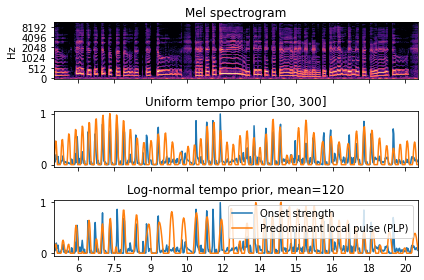

In [7]:
fig, ax = plt.subplots(nrows=3, sharex=True)
librosa.display.specshow(librosa.power_to_db(melspec,ref=np.max),
                         x_axis='time', y_axis='mel', ax=ax[0])

ax[0].set(title='Mel spectrogram')
ax[0].label_outer()

ax[1].plot(librosa.times_like(onset_env),
         librosa.util.normalize(onset_env),
         label='Onset strength')
ax[1].plot(librosa.times_like(pulse),
         librosa.util.normalize(pulse),
         label='Predominant local pulse (PLP)')
ax[1].set(title='Uniform tempo prior [30, 300]')
ax[1].label_outer()

ax[2].plot(librosa.times_like(onset_env),
         librosa.util.normalize(onset_env),
         label='Onset strength')
ax[2].plot(librosa.times_like(pulse_lognorm),
         librosa.util.normalize(pulse_lognorm),
         label='Predominant local pulse (PLP)')
ax[2].set(title='Log-normal tempo prior, mean=120', xlim=[5, 20])
ax[2].legend()

plt.tight_layout()
#plt.savefig("PLP compared to onset envelope.png", format="png")

- Use PLP local maxima as estimates of beat positions.

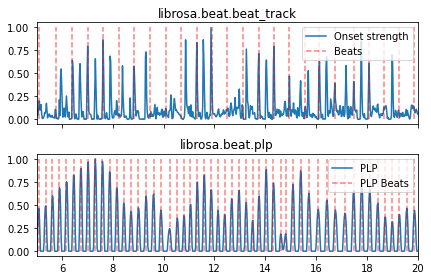

In [9]:
tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env)
beats_plp = np.flatnonzero(librosa.util.localmax(pulse))

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
times = librosa.times_like(onset_env, sr=sr)

ax[0].plot(times, librosa.util.normalize(onset_env),
         label='Onset strength')
ax[0].vlines(times[beats], 0, 1, alpha=0.5, color='r',
           linestyle='--', label='Beats')
ax[0].legend()
ax[0].set(title='librosa.beat.beat_track')
ax[0].label_outer()

    # Limit the plot to a 15-second window
times = librosa.times_like(pulse, sr=sr)

ax[1].plot(times, librosa.util.normalize(pulse),
         label='PLP')
ax[1].vlines(times[beats_plp], 0, 1, alpha=0.5, color='r',
           linestyle='--', label='PLP Beats')
ax[1].legend()
ax[1].set(title='librosa.beat.plp', xlim=[5, 20])
ax[1].xaxis.set_major_formatter(librosa.display.TimeFormatter())

plt.tight_layout()
#plt.savefig("PLP local max estimates beat positions.png", format="png")